# DCE phantom simulator

Three-circle phantom, DCE time courses, golden-angle stack-of-stars radial + Cartesian reference k-space, saved 

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import map_coordinates

## Params

In [2]:
# square image matrix
N       = 256
os_fac  = 4
N_os    = N * os_fac
n_z     = 1
C       = 8

# dce timing (seconds)
duration = 60.0
T_rad  = 5
T_cart = 4
n_gt   = 61
t_rad  = np.linspace(0, duration, T_rad).astype(np.float32)
t_cart = np.linspace(0, duration, T_cart).astype(np.float32)
t_gt   = np.linspace(0, duration, n_gt).astype(np.float32)

# MR sequence (spoiled gradient echo)
mr = dict(
    flip_deg   = 12.0,
    TR_s       = 4.0e-3,
    relaxivity = 5.0,       # s^-1 mM^-1 (Gd at 1.5T)
)

# arterial input function (cosine-bolus + exponential washout, XCAT-ERIC style)
Hct = 0.4
aif_params = dict(
    ab = 2.84 / (1.0 - Hct),   # bolus amplitude (mM)
    mb = 22.8,                 # bolus duration constant (1/s)
    ae = 1.36,                 # washout amplitude
    me = 0.171,                # washout rate (1/s)
    t0 = 5.0,                  # bolus onset (s)
)

# phantom circles with PK + baseline tissue params
# ve, vp dimensionless; ke in 1/min; delay in s; T1_0_ms baseline T1 in ms; S0 spin-density weight
circles = [
    # big background: liver-like (moderate ke, low vp)
    dict(cx=N//2,      cy=N//2,      r=90,
         ve=0.29, vp=0.01, ke=1.09, delay=15.0, T1_0_ms=800.0,  S0=1.0),
    # slow-enhancing lesion (low permeability)
    dict(cx=N//2 - 35, cy=N//2 - 45, r=22,
         ve=0.25, vp=0.005, ke=0.30, delay=10.0, T1_0_ms=1200.0, S0=1.0),
    # fast-enhancing lesion (tumor-like)
    dict(cx=N//2 + 30, cy=N//2 + 40, r=15,
         ve=0.40, vp=0.05, ke=1.50, delay=5.0,  T1_0_ms=1400.0, S0=1.0),
]

# coils
coil_ring_frac  = 0.85
coil_sigma_frac = 0.4

# radial acquisition
n_spokes_rad = 213
RO           = N
ga_rad       = np.pi * (3.0 - np.sqrt(5.0))

cart_density = 1.0
noise_std    = 0.0

seed     = 0
out_dir  = Path('/scratch/rnga/vvpshenov/DCE_NIK')
out_rad  = out_dir / 'sim_phantom_rad.h5'
out_cart = out_dir / 'sim_phantom_cart.h5'

np.random.seed(seed)
print(f'image {N}x{N}   oversample {os_fac}x -> grid {N_os}x{N_os}')
print(f'coils {C}   n_z {n_z}')
print(f'T_rad {T_rad}   T_cart {T_cart}   n_gt {n_gt}   duration {duration}s')
print(f'spokes {n_spokes_rad}   RO {RO}')
print(f'mr: flip={mr["flip_deg"]} deg, TR={mr["TR_s"]*1e3} ms, r1={mr["relaxivity"]} /s/mM')
print(f'aif: ab={aif_params["ab"]:.2f} mM, mb={aif_params["mb"]} /s, ae={aif_params["ae"]}, me={aif_params["me"]} /s, t0={aif_params["t0"]} s')

image 256x256   oversample 4x -> grid 1024x1024
coils 8   n_z 1
T_rad 5   T_cart 4   n_gt 61   duration 60.0s
spokes 213   RO 256
mr: flip=12.0 deg, TR=4.0 ms, r1=5.0 /s/mM
aif: ab=4.73 mM, mb=22.8 /s, ae=1.36, me=0.171 /s, t0=5.0 s


## DCE PK model

Cosine-bolus AIF + extended Tofts-Kety + SPGR signal (mirrors XCAT-ERIC):
- AIF: `cp(t) = ab·bolus(t - t0) + ab·ae·(bolus ⊛ exp(-me·t))`, bolus = raised cosine on `[0, 2π/mb]`
- Tissue: `ct(t) = vp·cp(t - delay) + ve·ke·∫cp(τ-delay)·exp(-ke(t-τ))dτ`
- Relaxation: `R1(t) = R1_0 + r1·ct(t)`
- SPGR steady-state: `S = S0 · sin(α) · (1 - E1) / (1 - cos(α)·E1)`, `E1 = exp(-TR/T1(t))`

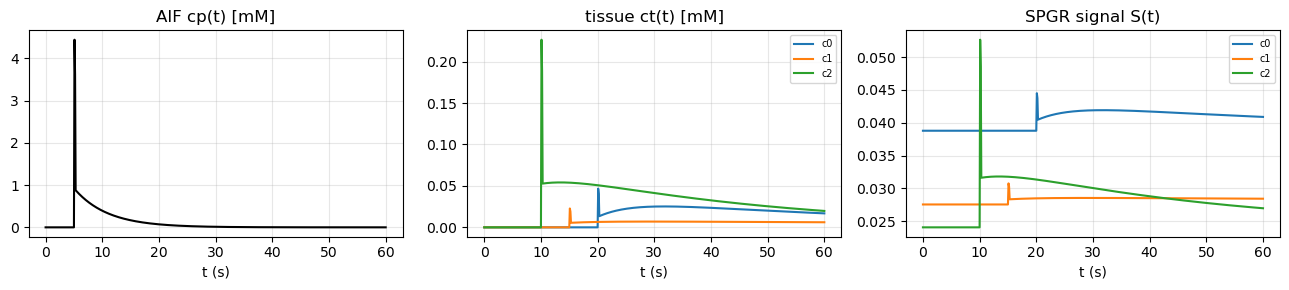

In [3]:
def cosine_aif(t, ab, mb, ae, me, t0):
    # t uniform, seconds. Returns cp in mM.
    dt  = t[1] - t[0]
    tau = t - t0
    bolus_dur = 2 * np.pi / mb
    bolus = np.zeros_like(t, dtype=np.float64)
    m = (tau >= 0) & (tau <= bolus_dur)
    bolus[m] = 0.5 * (1.0 - np.cos(mb * tau[m]))
    # exp decay kernel anchored at t[0]; causal convolution
    exp_kern = np.exp(-me * (t - t[0]))
    conv = dt * np.convolve(bolus, exp_kern, mode='full')[:len(t)]
    return np.clip(ab * bolus + ab * ae * conv, 0.0, None)

def extended_tofts(t, cp, ve, vp, ke_min, delay_s=0.0):
    # ct(t) = vp*cp(t-delay) + ve*ke*conv(cp(t-delay), exp(-ke*t))
    dt = t[1] - t[0]
    ke = ke_min / 60.0                              # 1/min -> 1/s
    n_shift = max(0, int(round(delay_s / dt)))
    cp_d = np.concatenate([np.zeros(n_shift), cp[:len(cp) - n_shift]]) if n_shift > 0 else cp
    kernel = ke * np.exp(-ke * (t - t[0]))
    ce = dt * np.convolve(cp_d, kernel, mode='full')[:len(cp_d)]
    return vp * cp_d + ve * ce

def spgr_signal(T1_s, TR_s, flip_rad, S0=1.0):
    E1 = np.exp(-TR_s / np.clip(T1_s, 1e-6, None))
    return S0 * np.sin(flip_rad) * (1.0 - E1) / (1.0 - np.cos(flip_rad) * E1 + 1e-20)

def compute_dce_signal(t, circle, aif_params, mr):
    cp   = cosine_aif(t, **aif_params)
    ct   = extended_tofts(t, cp, circle['ve'], circle['vp'], circle['ke'], circle['delay'])
    R1_0 = 1000.0 / circle['T1_0_ms']               # 1/s (from ms)
    R1_t = R1_0 + mr['relaxivity'] * ct             # 1/s
    T1_t = 1.0 / R1_t                               # s
    flip = np.deg2rad(mr['flip_deg'])
    return spgr_signal(T1_t, mr['TR_s'], flip, circle['S0'])

# fine grid for convolution accuracy
t_fine = np.arange(0.0, duration + 0.1, 0.1).astype(np.float64)
cp_fine = cosine_aif(t_fine, **aif_params)

fig, ax = plt.subplots(1, 3, figsize=(13, 3))
ax[0].plot(t_fine, cp_fine, 'k'); ax[0].set_title('AIF cp(t) [mM]'); ax[0].set_xlabel('t (s)'); ax[0].grid(alpha=0.3)
for i, c in enumerate(circles):
    ct = extended_tofts(t_fine, cp_fine, c['ve'], c['vp'], c['ke'], c['delay'])
    ax[1].plot(t_fine, ct, label=f'c{i}')
ax[1].set_title('tissue ct(t) [mM]'); ax[1].set_xlabel('t (s)'); ax[1].legend(fontsize=7); ax[1].grid(alpha=0.3)
for i, c in enumerate(circles):
    s = compute_dce_signal(t_fine, c, aif_params, mr)
    ax[2].plot(t_fine, s, label=f'c{i}')
ax[2].set_title('SPGR signal S(t)'); ax[2].set_xlabel('t (s)'); ax[2].legend(fontsize=7); ax[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Phantom image stack

gt nominal: (61, 256, 256)   rad nominal: (5, 256, 256)
rad os    : (5, 1024, 1024)   cart os   : (4, 1024, 1024)


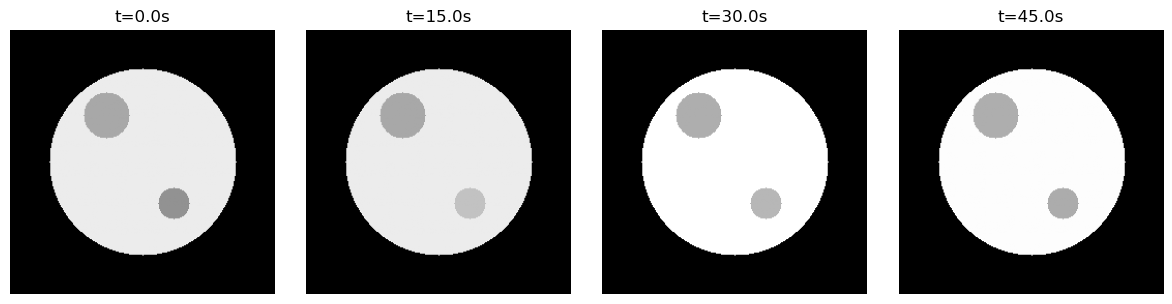

In [4]:
def build_phantom_stack(t_vec, N_img, circles_img, aif_params, mr, t_fine):
    Y, X = np.mgrid[:N_img, :N_img]
    n_t  = len(t_vec)
    out  = np.zeros((n_t, N_img, N_img), dtype=np.float32)
    for c in circles_img:
        mask = ((X - c['cx'])**2 + (Y - c['cy'])**2) <= c['r']**2
        S_fine = compute_dce_signal(t_fine, c, aif_params, mr)
        S_samp = np.interp(t_vec, t_fine, S_fine).astype(np.float32)
        for ti in range(n_t):
            out[ti, mask] = S_samp[ti]
    return out

def scale_circles(circles, factor):
    # scale geometry only; PK + tissue params stay the same
    return [dict(c, cx=c['cx']*factor, cy=c['cy']*factor, r=c['r']*factor) for c in circles]

# nominal-resolution versions for storage as GT
img_gt   = build_phantom_stack(t_gt,   N, circles, aif_params, mr, t_fine)
img_rad  = build_phantom_stack(t_rad,  N, circles, aif_params, mr, t_fine)
img_cart = build_phantom_stack(t_cart, N, circles, aif_params, mr, t_fine)

# oversampled for FFT
circles_os  = scale_circles(circles, os_fac)
img_rad_os  = build_phantom_stack(t_rad,  N_os, circles_os, aif_params, mr, t_fine)
img_cart_os = build_phantom_stack(t_cart, N_os, circles_os, aif_params, mr, t_fine)

print('gt nominal:', img_gt.shape, '  rad nominal:', img_rad.shape)
print('rad os    :', img_rad_os.shape, '  cart os   :', img_cart_os.shape)

fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for i, ti in enumerate([0, n_gt//4, n_gt//2, 3*n_gt//4]):
    ax[i].imshow(img_gt[ti], cmap='gray', vmin=0, vmax=img_gt.max())
    ax[i].set_title(f't={t_gt[ti]:.1f}s'); ax[i].axis('off')
plt.tight_layout(); plt.show()

## Coil sensitivity maps

coil_maps nominal: (8, 256, 256)    coil_maps os: (8, 1024, 1024)


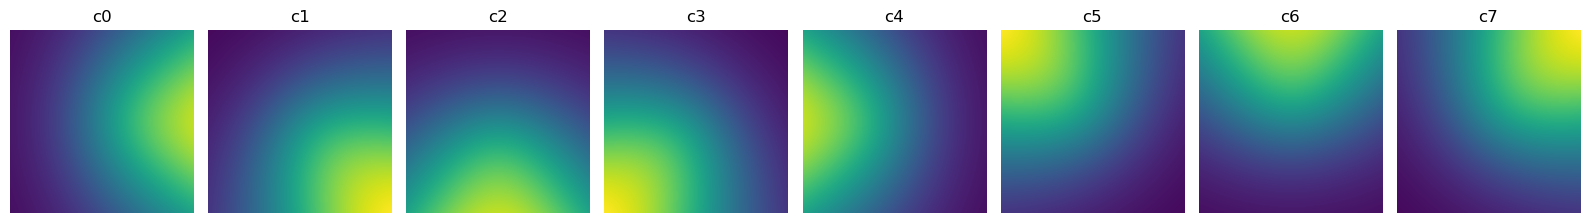

In [5]:
def build_coil_maps(C, N_img, ring_frac=0.85, sigma_frac=0.4):
    Y, X = np.mgrid[:N_img, :N_img]
    c0  = N_img / 2.0
    R   = ring_frac * N_img / 2.0
    sig = sigma_frac * N_img
    maps = np.zeros((C, N_img, N_img), dtype=np.float64)
    for c in range(C):
        theta = 2 * np.pi * c / C
        cx = c0 + R * np.cos(theta)
        cy = c0 + R * np.sin(theta)
        maps[c] = np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sig**2))
    rss = np.sqrt(np.sum(maps**2, axis=0, keepdims=True)) + 1e-8
    return (maps / rss).astype(np.float64)

coil_maps    = build_coil_maps(C, N,    coil_ring_frac, coil_sigma_frac)   # nominal, for storage
coil_maps_os = build_coil_maps(C, N_os, coil_ring_frac, coil_sigma_frac)   # oversampled, for FFT
print('coil_maps nominal:', coil_maps.shape, '   coil_maps os:', coil_maps_os.shape)

vmax = float(coil_maps.max())
fig, ax = plt.subplots(1, C, figsize=(2*C, 2.2))
for c in range(C):
    ax[c].imshow(coil_maps[c], cmap='viridis', vmin=0, vmax=vmax); ax[c].set_title(f'c{c}'); ax[c].axis('off')
plt.tight_layout(); plt.show()

## Cartesian k-space (full FFT grid)

In [6]:
def image_to_k_full(img_stack, coil_maps):
    # img_stack (T, N, N) real, coil_maps (C, N, N) real
    # returns (T, C, N, N) complex, centered (DC at N//2)
    imgs_c = img_stack[:, None, :, :] * coil_maps[None, :, :, :]
    k = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(imgs_c, axes=(-2, -1)), norm='ortho'),
                        axes=(-2, -1))
    return k.astype(np.complex64)

# oversampled k-space for both radial and cartesian sampling
k_cart_os = image_to_k_full(img_cart_os, coil_maps_os)   # (T_cart, C, N_os, N_os)
k_rad_os  = image_to_k_full(img_rad_os,  coil_maps_os)   # (T_rad,  C, N_os, N_os)
print('k_cart_os:', k_cart_os.shape, '   k_rad_os:', k_rad_os.shape)

# cartesian reference = central N x N crop of oversampled k-space
c0 = (N_os - N) // 2
k_cart_full = k_cart_os[:, :, c0:c0+N, c0:c0+N]          # (T_cart, C, N, N)
print('k_cart_full (nominal crop):', k_cart_full.shape)

# cartesian subsampling mask (optional)
if cart_density < 1.0:
    mask_cart = (np.random.rand(N, N) < cart_density).astype(np.float32)
    k_cart_full = k_cart_full * mask_cart[None, None, :, :]
    print(f'cart subsampled to density {cart_density:.2f}')

# noise added to the sampled/stored tensors
def add_noise(k, std):
    return k + (std * (np.random.randn(*k.shape) + 1j * np.random.randn(*k.shape))).astype(np.complex64)

if noise_std > 0:
    k_cart_full = add_noise(k_cart_full, noise_std)

k_cart_os: (4, 8, 1024, 1024)    k_rad_os: (5, 8, 1024, 1024)
k_cart_full (nominal crop): (4, 8, 256, 256)


## Radial golden-angle stack-of-stars (single z-slice)

k_rad: (5, 8, 213, 256)
kx/ky_rad: (5, 213, 256)


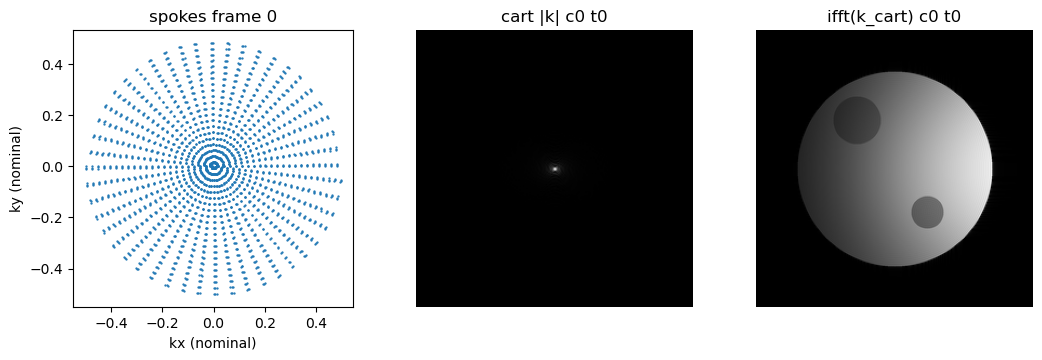

In [7]:
def golden_angle_spokes(n_spokes, RO, frame_idx=0, ga=ga_rad):
    start  = frame_idx * n_spokes
    angles = ((np.arange(start, start + n_spokes) * ga) % np.pi).astype(np.float32)
    kr     = np.linspace(-0.5, 0.5 - 1.0 / RO, RO).astype(np.float32)   # nominal units
    kx     = kr[None, :] * np.cos(angles[:, None])                      # (S, RO)
    ky     = kr[None, :] * np.sin(angles[:, None])
    return kx, ky, angles

def sample_kgrid_os(k_os, kx_nom, ky_nom, N_nom, N_os):
    # k_os: (C, N_os, N_os) complex, centered
    # kx_nom, ky_nom in nominal units [-0.5, 0.5 - 1/N_nom]
    # pixel index on oversampled grid: px = kx_nom * N_nom + N_os/2
    C_ = k_os.shape[0]
    px = kx_nom * N_nom + N_os / 2.0
    py = ky_nom * N_nom + N_os / 2.0
    coords = np.stack([py, px], axis=0)
    out = np.zeros((C_,) + kx_nom.shape, dtype=np.complex64)
    for c in range(C_):
        re = map_coordinates(k_os[c].real, coords, order=1, mode='constant', cval=0.0)
        im = map_coordinates(k_os[c].imag, coords, order=1, mode='constant', cval=0.0)
        out[c] = re + 1j * im
    return out

kx_rad = np.zeros((T_rad, n_spokes_rad, RO), dtype=np.float32)
ky_rad = np.zeros_like(kx_rad)
kz_rad = np.zeros_like(kx_rad)                                   # single z-slice
k_rad  = np.zeros((T_rad, C, n_spokes_rad, RO), dtype=np.complex64)

for t in range(T_rad):
    kx_t, ky_t, _ = golden_angle_spokes(n_spokes_rad, RO, frame_idx=t)
    kx_rad[t] = kx_t
    ky_rad[t] = ky_t
    k_rad[t]  = sample_kgrid_os(k_rad_os[t], kx_t, ky_t, N, N_os)

if noise_std > 0:
    k_rad = add_noise(k_rad, noise_std)

print('k_rad:',  k_rad.shape)
print('kx/ky_rad:', kx_rad.shape)

fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))
ax[0].scatter(kx_rad[0, ::3, ::6].flatten(), ky_rad[0, ::3, ::6].flatten(), s=0.4)
ax[0].set_aspect('equal'); ax[0].set_title('spokes frame 0')
ax[0].set_xlabel('kx (nominal)'); ax[0].set_ylabel('ky (nominal)')
ax[1].imshow(np.log1p(np.abs(k_cart_full[0, 0])), cmap='gray'); ax[1].set_title('cart |k| c0 t0'); ax[1].axis('off')
img_back = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k_cart_full[0, 0]), norm='ortho'))
ax[2].imshow(np.abs(img_back), cmap='gray'); ax[2].set_title('ifft(k_cart) c0 t0'); ax[2].axis('off')
plt.tight_layout(); plt.show()

## Save to HDF5 (DCE_NIK format)

- `/results/kspace/DCE`       : radial `(T, C, S, RO)` complex64  |  cart `(T, C, kz, ky, kx)` complex64
- `/results/kspace/trajDCE`   : radial `(T, 3, S, RO)` float32    |  cart: n/a
- `/results/kspace/coilMaps`  : `(C, kz, H, W)` float64
- `/results/images/GroundTruth/img`    : `(n_gt, kz, H, W)` float32
- `/results/images/GroundTruth/timing` : `(n_gt,)` float32
- `/results/kspace/meta/matrixRL, matrixAP, matrixFH` : int

In [8]:
def save_radial(path, k, kx, ky, kz, coil_maps, gt_imgs, gt_times, N_nom):
    # k (T, C, S, RO), kx/ky/kz (T, S, RO), coil_maps (C, N, N), gt_imgs (n_gt, N, N)
    traj = np.stack([kx, ky, kz], axis=1).astype(np.float32)
    with h5py.File(path, 'w') as f:
        f.create_dataset('/results/kspace/DCE',      data=k.astype(np.complex64))
        f.create_dataset('/results/kspace/trajDCE',  data=traj)
        f.create_dataset('/results/kspace/coilMaps', data=coil_maps[:, None, :, :].astype(np.float64))
        f.create_dataset('/results/images/GroundTruth/img',    data=gt_imgs[:, None, :, :].astype(np.float32))
        f.create_dataset('/results/images/GroundTruth/timing', data=gt_times.astype(np.float32))
        f.create_dataset('/results/kspace/meta/matrixRL', data=np.array([N_nom], dtype=np.int32))
        f.create_dataset('/results/kspace/meta/matrixAP', data=np.array([N_nom], dtype=np.int32))
        f.create_dataset('/results/kspace/meta/matrixFH', data=np.array([1],     dtype=np.int32))
    print(f'saved {path}')

def save_cartesian(path, k_full, coil_maps, gt_imgs, gt_times, N_nom):
    # square: no transpose needed. store (T, C, 1, N, N)
    k_store = k_full[:, :, None, :, :].astype(np.complex64)
    with h5py.File(path, 'w') as f:
        f.create_dataset('/results/kspace/DCE',      data=k_store)
        f.create_dataset('/results/kspace/coilMaps', data=coil_maps[:, None, :, :].astype(np.float64))
        f.create_dataset('/results/images/GroundTruth/img',    data=gt_imgs[:, None, :, :].astype(np.float32))
        f.create_dataset('/results/images/GroundTruth/timing', data=gt_times.astype(np.float32))
        f.create_dataset('/results/kspace/meta/matrixRL', data=np.array([N_nom], dtype=np.int32))
        f.create_dataset('/results/kspace/meta/matrixAP', data=np.array([N_nom], dtype=np.int32))
        f.create_dataset('/results/kspace/meta/matrixFH', data=np.array([1],     dtype=np.int32))
    print(f'saved {path}')

save_radial(out_rad,  k_rad,  kx_rad, ky_rad, kz_rad, coil_maps, img_gt, t_gt, N)
save_cartesian(out_cart, k_cart_full, coil_maps, img_gt, t_gt, N)

saved /scratch/rnga/vvpshenov/DCE_NIK/sim_phantom_rad.h5
saved /scratch/rnga/vvpshenov/DCE_NIK/sim_phantom_cart.h5


## Sanity reload + quick reconstruction

radial    k: (5, 8, 213, 256)    traj: (5, 3, 213, 256)    coil_maps: (8, 1, 256, 256)    gt: (61, 1, 256, 256)
cartesian k: (4, 8, 1, 256, 256)    coil_maps: (8, 1, 256, 256)    gt: (61, 1, 256, 256)


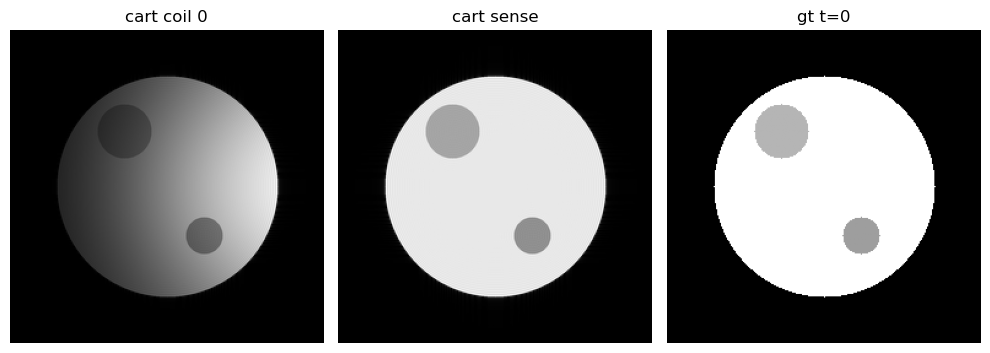

In [9]:
from nik_io import load_event, load_cartesian_kspace

ev  = load_event(str(out_rad),  load_images=True, load_coil_maps=True)
cev = load_cartesian_kspace(str(out_cart), load_images=True, load_coil_maps=True)
print('radial    k:', ev['k'].shape,  '   traj:', ev['traj'].shape,  '   coil_maps:', ev['coil_maps'].shape,  '   gt:', ev['gt_img'].shape)
print('cartesian k:', cev['k_cart'].shape, '   coil_maps:', cev['coil_maps'].shape, '   gt:', cev['gt_img'].shape)

# cartesian single-coil and SENSE recon
k_all = cev['k_cart'][0, :, 0, :, :]                     # (C, N, N)
coil_imgs = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k_all, axes=(-2, -1)), norm='ortho'), axes=(-2, -1))
sens = cev['coil_maps'][:, 0, :, :].astype(np.complex64)  # (C, N, N)
denom = np.sum(np.abs(sens)**2, axis=0) + 1e-10
img_sense = np.abs(np.sum(np.conj(sens) * coil_imgs, axis=0) / denom)

fig, ax = plt.subplots(1, 3, figsize=(10, 3.5))
ax[0].imshow(np.abs(coil_imgs[0]), cmap='gray'); ax[0].set_title('cart coil 0'); ax[0].axis('off')
ax[1].imshow(img_sense,            cmap='gray'); ax[1].set_title('cart sense'); ax[1].axis('off')
ax[2].imshow(cev['gt_img'][0, 0],  cmap='gray'); ax[2].set_title('gt t=0');     ax[2].axis('off')
plt.tight_layout(); plt.show()

## PK sweep (ke x ve, for viewer)

Varies `ke` and `ve` of one ROI, fixes everything else. Builds a small (`N=128`) image + k-space tensor across all combinations and all time points. Saved to `sim_pk_sweep.h5` for interactive exploration in a separate viewer notebook.

In [10]:
import time, json

# sweep params
sweep_roi_idx = 2                # which circle to sweep (2 = fast lesion)
sweep_N       = 128
sweep_os      = 4
sweep_N_os    = sweep_N * sweep_os
sweep_n_t     = 30
sweep_t       = np.linspace(0.0, duration, sweep_n_t).astype(np.float32)

ke_values = np.linspace(0.1, 2.0, 12).astype(np.float32)   # 1/min
ve_values = np.linspace(0.1, 0.6,  6).astype(np.float32)

out_sweep = out_dir / 'sim_pk_sweep.h5'

# rescale circle geometry from N -> sweep_N; PK params unchanged
s2sweep = sweep_N / N
circles_sw_nom = [dict(c, cx=c['cx']*s2sweep, cy=c['cy']*s2sweep, r=c['r']*s2sweep) for c in circles]
circles_sw_os  = scale_circles(circles_sw_nom, sweep_os)

bg_nom = [c for i, c in enumerate(circles_sw_nom) if i != sweep_roi_idx]
bg_os  = [c for i, c in enumerate(circles_sw_os)  if i != sweep_roi_idx]
swept_nom = circles_sw_nom[sweep_roi_idx]
swept_os  = circles_sw_os[sweep_roi_idx]

t_fine_sw = np.arange(0.0, duration + 0.1, 0.1).astype(np.float64)
cp_fine_sw = cosine_aif(t_fine_sw, **aif_params)

# precompute background image stacks (they don't depend on swept params)
img_bg_os  = (build_phantom_stack(sweep_t, sweep_N_os, bg_os,  aif_params, mr, t_fine_sw)
              if bg_os  else np.zeros((sweep_n_t, sweep_N_os, sweep_N_os), np.float32))
img_bg_nom = (build_phantom_stack(sweep_t, sweep_N,    bg_nom, aif_params, mr, t_fine_sw)
              if bg_nom else np.zeros((sweep_n_t, sweep_N, sweep_N), np.float32))

# swept-ROI masks at both scales
Y_os, X_os = np.mgrid[:sweep_N_os, :sweep_N_os]
Y,    X    = np.mgrid[:sweep_N,    :sweep_N]
mask_sw_os  = ((X_os - swept_os['cx'])**2 + (Y_os - swept_os['cy'])**2) <= swept_os['r']**2
mask_sw_nom = ((X    - swept_nom['cx'])**2 + (Y    - swept_nom['cy'])**2) <= swept_nom['r']**2

# crop offset for os -> nominal kspace
c0_sw = (sweep_N_os - sweep_N) // 2

# cp at sweep timings (shared across all combos)
cp_at_sweep_t = np.interp(sweep_t, t_fine_sw, cp_fine_sw).astype(np.float32)

# output tensors
n_ke, n_ve = len(ke_values), len(ve_values)
image_sweep  = np.zeros((n_ke, n_ve, sweep_n_t, sweep_N, sweep_N), dtype=np.float32)
kspace_sweep = np.zeros((n_ke, n_ve, sweep_n_t, sweep_N, sweep_N), dtype=np.complex64)
ct_sweep     = np.zeros((n_ke, n_ve, sweep_n_t), dtype=np.float32)

print(f'sweep: {n_ke} ke x {n_ve} ve x {sweep_n_t} t  at {sweep_N}x{sweep_N}')
print(f'storage: image {image_sweep.nbytes/1e6:.1f} MB   kspace {kspace_sweep.nbytes/1e6:.1f} MB')
print(f'sweeping ROI {sweep_roi_idx}  (fixed: vp={swept_nom["vp"]}, delay={swept_nom["delay"]}s, T1_0={swept_nom["T1_0_ms"]}ms)')

t0 = time.time()
for ke_i, ke in enumerate(ke_values):
    for ve_i, ve in enumerate(ve_values):
        swept_params = dict(swept_nom, ke=float(ke), ve=float(ve))
        # signal for swept ROI
        S_fine = compute_dce_signal(t_fine_sw, swept_params, aif_params, mr)
        S_samp = np.interp(sweep_t, t_fine_sw, S_fine).astype(np.float32)
        # tissue ct trace
        ct_fine = extended_tofts(t_fine_sw, cp_fine_sw, float(ve), swept_params['vp'],
                                 float(ke), swept_params['delay'])
        ct_sweep[ke_i, ve_i] = np.interp(sweep_t, t_fine_sw, ct_fine).astype(np.float32)
        # overlay on background
        img_os_cur  = img_bg_os.copy()
        img_nom_cur = img_bg_nom.copy()
        for ti in range(sweep_n_t):
            img_os_cur[ti,  mask_sw_os]  = S_samp[ti]
            img_nom_cur[ti, mask_sw_nom] = S_samp[ti]
        # fft + crop to nominal
        k_os = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img_os_cur, axes=(-2, -1)), norm='ortho'),
                               axes=(-2, -1))
        image_sweep[ke_i, ve_i]  = img_nom_cur
        kspace_sweep[ke_i, ve_i] = k_os[:, c0_sw:c0_sw+sweep_N, c0_sw:c0_sw+sweep_N].astype(np.complex64)
    print(f'  ke={ke:.2f} ({ke_i+1}/{n_ke})  elapsed {time.time()-t0:.1f}s')

# save
with h5py.File(out_sweep, 'w') as f:
    g = f.create_group('/sweep')
    g.create_dataset('params/ke', data=ke_values)
    g.create_dataset('params/ve', data=ve_values)
    g.create_dataset('times',     data=sweep_t)
    g.create_dataset('image',  data=image_sweep,  chunks=(1, 1, 1, sweep_N, sweep_N), compression='lzf')
    g.create_dataset('kspace', data=kspace_sweep, chunks=(1, 1, 1, sweep_N, sweep_N), compression='lzf')
    g.create_dataset('pk/ct',      data=ct_sweep)
    g.create_dataset('pk/cp',      data=cp_at_sweep_t)
    g.create_dataset('pk/roi_idx', data=np.array([sweep_roi_idx], dtype=np.int32))
    meta = {
        'N': int(sweep_N), 'os_fac': int(sweep_os),
        'duration_s': float(duration), 'sweep_roi_idx': int(sweep_roi_idx),
        'aif_params': {k: float(v) for k, v in aif_params.items()},
        'mr':         {k: float(v) for k, v in mr.items()},
        'fixed_circles': [{k: float(v) if isinstance(v, (int, float, np.floating, np.integer)) else v
                           for k, v in c.items()} for c in circles_sw_nom],
    }
    g.attrs['config_json'] = json.dumps(meta)

print(f'saved {out_sweep}')

sweep: 12 ke x 6 ve x 30 t  at 128x128
storage: image 141.6 MB   kspace 283.1 MB
sweeping ROI 2  (fixed: vp=0.05, delay=5.0s, T1_0=1400.0ms)
  ke=0.10 (1/12)  elapsed 1.7s
  ke=0.27 (2/12)  elapsed 3.5s
  ke=0.45 (3/12)  elapsed 5.2s
  ke=0.62 (4/12)  elapsed 6.8s
  ke=0.79 (5/12)  elapsed 8.8s
  ke=0.96 (6/12)  elapsed 10.9s
  ke=1.14 (7/12)  elapsed 12.6s
  ke=1.31 (8/12)  elapsed 14.4s
  ke=1.48 (9/12)  elapsed 16.4s
  ke=1.65 (10/12)  elapsed 18.8s
  ke=1.83 (11/12)  elapsed 20.8s
  ke=2.00 (12/12)  elapsed 23.0s
saved /scratch/rnga/vvpshenov/DCE_NIK/sim_pk_sweep.h5
